# Validacion del Modulo Predictivo - Datos de BD (Pipeline)

Este notebook **no ejecuta ningun calculo VPM**. Solo LEE los resultados ya
persistidos por el pipeline en `predicciones_ventana` y los compara contra
el rendimiento del pipeline (`produccion_acumulada_ciclo.rendimiento`).

**BD:** pruebas (solo lectura). No se escribe nada.

Usa las funciones existentes de `utils.queries`.

In [1]:
import sys, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.notebook import tqdm

from utils.conexionDB import set_db_path, get_db_path
from utils.queries import cargar_ciclos_historicos, cargar_predicciones_ciclo
from config import GPKG_PRUEBAS_PATH

set_db_path(GPKG_PRUEBAS_PATH)
print("BD:", get_db_path())


2026-07-18 12:20:48.645 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.647 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.648 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.649 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.650 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.651 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.652 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.652 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-

BD: c:\Users\mayno\Desktop\SeminarioInvestigacion\segmentacion_clasificacion_estimacion_maiz_comayagua\notebooks\..\data\pipeline_pruebas.gpkg


## 1. Cargar ciclos historicos con rendimiento

Usa `cargar_ciclos_historicos()` de `utils.queries`.

In [2]:
df_ciclos = cargar_ciclos_historicos()
print(f"Total ciclos historicos: {len(df_ciclos)}")

# Filtrar solo los que tienen rendimiento
df_ciclos = df_ciclos.dropna(subset=["rendimiento"]).copy()
df_ciclos = df_ciclos[df_ciclos["estado_ciclo"] == "finalizado"]
print(f"Ciclos finalizados con rendimiento: {len(df_ciclos)}")
display(df_ciclos.head())


2026-07-18 12:20:48.856 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.857 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Total ciclos historicos: 281
Ciclos finalizados con rendimiento: 258


,id_ciclo,id_parcela,temporada,sos,t1,t2,t3,eos,rendimiento,produccion_total,lswi_max,estado_ciclo,clasificacion_final,fecha_inicio,fecha_fin
0,2693,14,postrera,2020-03-11,2020-04-10,2020-05-10,2020-06-09,2020-06-12,140.441881,341.595384,None,finalizado,Otro,2020-02-18,2020-06-12
1,2725,17,primera,2020-04-02,2020-05-02,2020-06-01,2020-07-01,2021-01-07,244.243500,1164.210729,None,finalizado,Otro,2020-02-13,2021-01-07
2,2737,18,primera,2020-04-07,2020-05-07,2020-06-06,2020-07-06,2020-06-28,77.106841,23.596081,None,finalizado,Otro,2020-03-19,2020-06-28
3,2791,4,primera,2020-04-24,2020-05-24,2020-06-23,2020-07-23,2020-08-14,146.646110,275.463132,None,finalizado,Otro,2020-03-31,2020-08-14
4,2755,2,primera,2020-04-25,2020-05-25,2020-06-24,2020-07-24,2020-08-15,155.628728,333.225058,None,finalizado,Otro,2020-04-02,2020-08-15


## 2. Cargar predicciones de BD por ciclo

Usa `cargar_predicciones_ciclo(id_ciclo)` de `utils.queries`.

In [3]:
def cargar_todas_predicciones(df_ciclos):
    """Carga predicciones T1/T2/T3/EOS para todos los ciclos."""
    dfs = []
    for _, ciclo in tqdm(df_ciclos.iterrows(), total=len(df_ciclos), desc="Cargando predicciones"):
        cid = int(ciclo["id_ciclo"])
        dfp = cargar_predicciones_ciclo(cid)
        if dfp is not None and not dfp.empty:
            dfp["id_ciclo"] = cid
            dfs.append(dfp)
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

df_pred = cargar_todas_predicciones(df_ciclos)
print(f"Predicciones cargadas: {len(df_pred)} filas")
ventanas = sorted(df_pred["ventana"].unique()) if not df_pred.empty else []
print(f"Ventanas disponibles: {ventanas}")
display(df_pred.head(10))


Cargando predicciones:   0%|          | 0/258 [00:00<?, ?it/s]

2026-07-18 12:20:48.908 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:20:48.909 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 12:20:48.914 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 12:20:48.918 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 12:20:48.922 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 12:20:48.926 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': mi

Predicciones cargadas: 983 filas
Ventanas disponibles: ['EOS', 'T1', 'T2', 'T3']


,id_prediccion,ventana,fecha_ventana,gpp_acumulado,npp_acumulado,rendimiento_estimado_qq_ha,rendimiento_estimado_qq_parcela,score_compuesto,score_pearson,score_magnitud_pendiente,cultivo_predicho,id_ciclo
0,10090,EOS,2020-06-12,1194.461200,597.230600,140.441881,341.595384,NaN,None,None,NaN,2693
1,10087,T1,2020-04-10,1249.573202,624.786601,146.921818,357.356470,21.061967,None,None,Otro,2693
2,10088,T2,2020-05-10,1693.695538,846.847769,199.140657,484.367828,27.909871,None,None,Otro,2693
3,10089,T3,2020-06-09,1403.572863,701.786431,165.028729,401.397727,NaN,None,None,NaN,2693
4,10209,EOS,2021-01-07,2077.296189,1038.648094,244.243500,1164.210729,NaN,None,None,NaN,2725
5,10206,T1,2020-05-02,635.631211,317.815605,74.735992,356.236477,0.0,None,None,Otro,2725
6,10207,T2,2020-06-01,791.361925,395.680963,93.046436,443.515012,0.0,None,None,Otro,2725
7,10208,T3,2020-07-01,713.353765,356.676883,83.874424,399.795711,NaN,None,None,NaN,2725
8,10253,EOS,2020-06-28,655.795333,327.897666,77.106841,23.596081,NaN,None,None,NaN,2737
9,10251,T1,2020-05-07,993.745396,496.872698,116.842199,35.755815,0.0,None,None,Otro,2737


## 3. Construir DataFrame de convergencia

In [4]:
def construir_convergencia(df_ciclos, df_pred):
    """Construye DataFrame con yield por ventana vs yield final."""
    rows = []
    for _, ciclo in df_ciclos.iterrows():
        id_ciclo = int(ciclo["id_ciclo"])
        row = {
            "id_ciclo": id_ciclo,
            "id_parcela": int(ciclo["id_parcela"]),
            "temporada": ciclo["temporada"],
            "yield_final_qq_ha": float(ciclo["rendimiento"]),
        }
        preds_ciclo = df_pred[df_pred["id_ciclo"] == id_ciclo]
        if preds_ciclo.empty:
            rows.append(row)
            continue
        for v in ["T1", "T2", "T3", "EOS"]:
            p = preds_ciclo[preds_ciclo["ventana"] == v]
            if not p.empty:
                y = float(p["rendimiento_estimado_qq_ha"].iloc[0])
                row[f"yield_{v.lower()}_qq_ha"] = y
                final = row["yield_final_qq_ha"]
                row[f"error_{v.lower()}_qq_ha"] = y - final
                row[f"error_pct_{v.lower()}"] = ((y - final) / final * 100) if final else None
            else:
                row[f"yield_{v.lower()}_qq_ha"] = None
                row[f"error_{v.lower()}_qq_ha"] = None
                row[f"error_pct_{v.lower()}"] = None
        rows.append(row)
    return pd.DataFrame(rows)

df_conv = construir_convergencia(df_ciclos, df_pred)
print(f"Total ciclos: {len(df_conv)}")
completos = df_conv.dropna(subset=["yield_t1_qq_ha", "yield_t2_qq_ha", "yield_t3_qq_ha", "yield_eos_qq_ha"])
print(f"Con 4 ventanas: {len(completos)}")
display(df_conv.head(10))


Total ciclos: 258
Con 4 ventanas: 191


,id_ciclo,id_parcela,temporada,yield_final_qq_ha,yield_t1_qq_ha,error_t1_qq_ha,error_pct_t1,yield_t2_qq_ha,error_t2_qq_ha,error_pct_t2,yield_t3_qq_ha,error_t3_qq_ha,error_pct_t3,yield_eos_qq_ha,error_eos_qq_ha,error_pct_eos
0,2693,14,postrera,140.441881,146.921818,6.479937,4.613963,199.140657,58.698775,41.795777,165.028729,24.586847,17.506777,140.441881,0.0,0.0
1,2725,17,primera,244.243500,74.735992,-169.507508,-69.401031,93.046436,-151.197064,-61.904233,83.874424,-160.369077,-65.659506,244.243500,0.0,0.0
2,2737,18,primera,77.106841,116.842199,39.735357,51.532856,130.812755,53.705914,69.651296,NaN,NaN,NaN,77.106841,0.0,0.0
3,2791,4,primera,146.646110,158.340716,11.694606,7.974713,133.370927,-13.275182,-9.052529,170.755227,24.109117,16.440339,146.646110,0.0,0.0
4,2755,2,primera,155.628728,188.953706,33.324978,21.413128,152.902298,-2.726430,-1.751881,174.955562,19.326834,12.418552,155.628728,0.0,0.0
5,2805,5,primera,155.007672,183.253331,28.245660,18.222104,149.847374,-5.160298,-3.329060,175.052417,20.044746,12.931454,155.007672,0.0,0.0
6,2779,3,primera,156.637934,178.122303,21.484369,13.715943,156.510504,-0.127430,-0.081353,173.825995,17.188062,10.973116,156.637934,0.0,0.0
7,2705,15,primera,100.833998,120.409571,19.575573,19.413664,127.572819,26.738821,26.517664,NaN,NaN,NaN,100.833998,0.0,0.0
8,2847,8,primera,143.773076,140.514726,-3.258350,-2.266314,175.242098,31.469022,21.887980,157.099347,13.326272,9.268962,143.773076,0.0,0.0
9,2615,0,primera,179.262083,161.373937,-17.888147,-9.978768,147.526838,-31.735245,-17.703267,168.770636,-10.491447,-5.852574,179.262083,0.0,0.0


## 4. Scatter T1/T2/T3/EOS vs rendimiento final

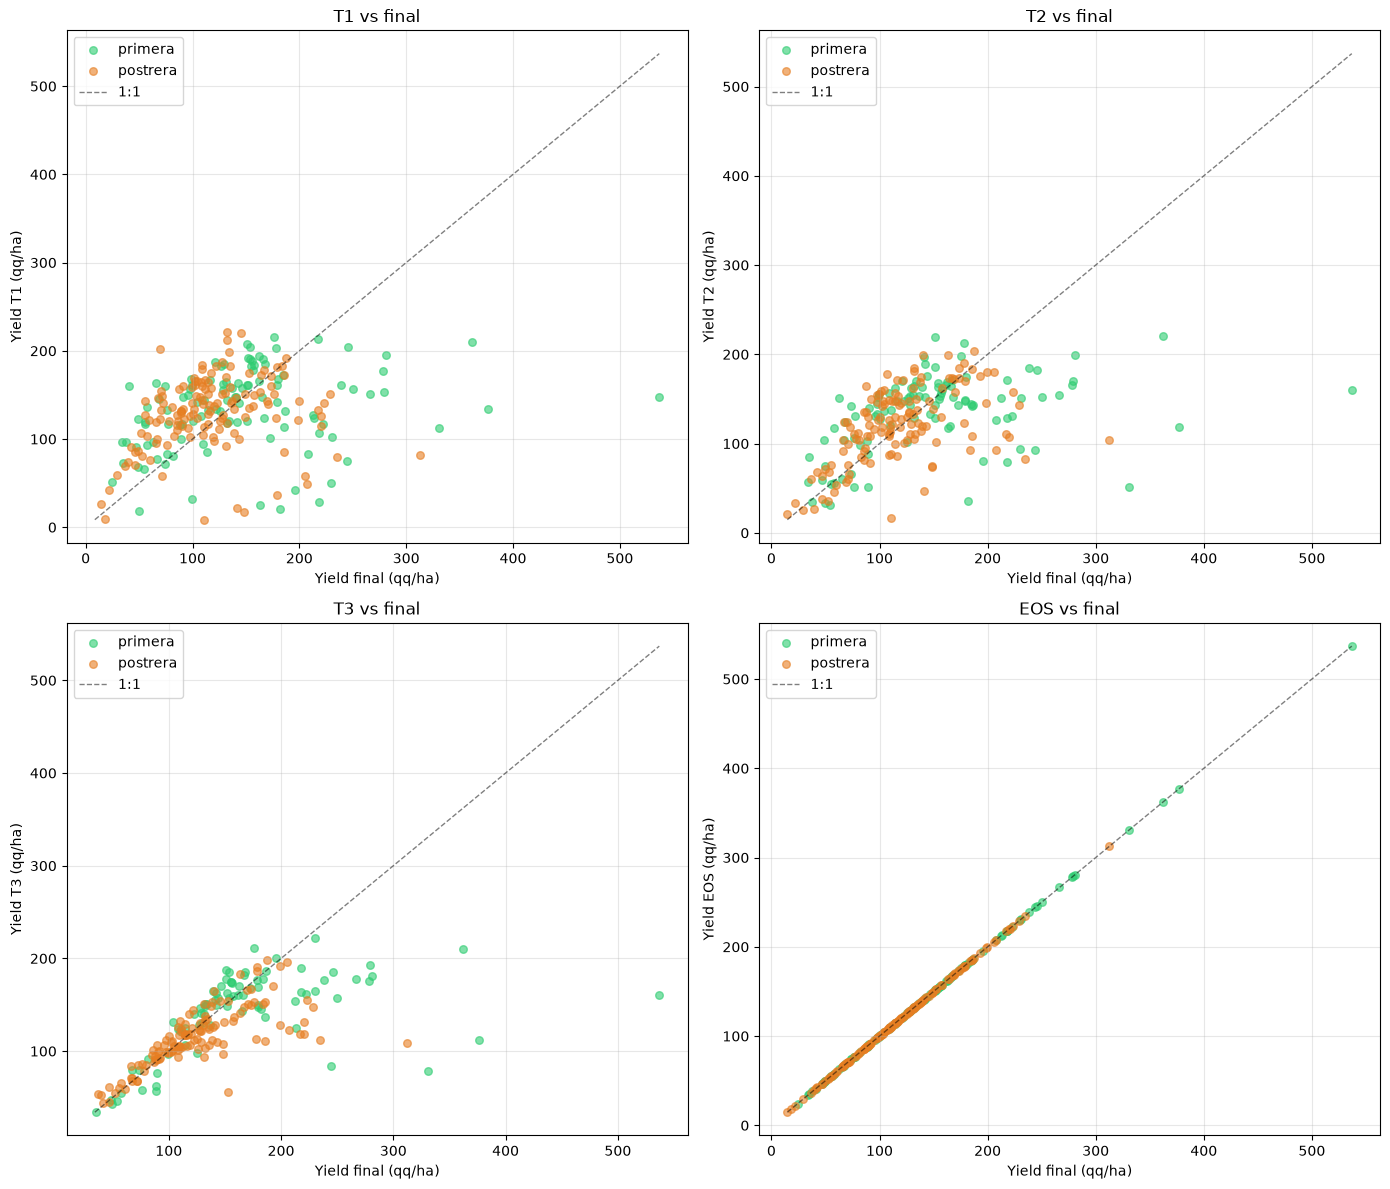

In [5]:
def graficar_scatter_convergencia(df_conv):
    ventanas = ["T1", "T2", "T3", "EOS"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, v in enumerate(ventanas):
        ax = axes[i]
        col_y = f"yield_{v.lower()}_qq_ha"
        sub = df_conv.dropna(subset=[col_y, "yield_final_qq_ha"])
        if sub.empty:
            ax.set_title(f"{v} - sin datos")
            continue

        for temp, color in [("primera", "#2ecc71"), ("postrera", "#e67e22")]:
            g = sub[sub["temporada"] == temp]
            if not g.empty:
                ax.scatter(g["yield_final_qq_ha"], g[col_y],
                           color=color, alpha=0.6, s=30, label=temp)

        lims = [
            min(sub["yield_final_qq_ha"].min(), sub[col_y].min()),
            max(sub["yield_final_qq_ha"].max(), sub[col_y].max()),
        ]
        ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="1:1")
        ax.set_xlabel("Yield final (qq/ha)")
        ax.set_ylabel(f"Yield {v} (qq/ha)")
        ax.set_title(f"{v} vs final")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig("scatter_convergencia_rendimiento_db.pdf", format="pdf", bbox_inches="tight")
    plt.show()

graficar_scatter_convergencia(df_conv)


## 5. Metricas de error

In [6]:
def calcular_metricas_error(df_conv):
    ventanas = ["T1", "T2", "T3", "EOS"]
    rows = []
    for v in ventanas:
        col_y = f"yield_{v.lower()}_qq_ha"
        sub = df_conv.dropna(subset=[col_y, "yield_final_qq_ha"])
        if sub.empty:
            continue
        real = sub["yield_final_qq_ha"].values
        pred = sub[col_y].values
        errors = pred - real
        abs_err = np.abs(errors)
        rows.append({
            "ventana": v,
            "n": len(sub),
            "rmse_qq_ha": float(np.sqrt(np.mean(errors**2))),
            "mae_qq_ha": float(np.mean(abs_err)),
            "mape_pct": float(np.mean(abs_err / real * 100)),
            "bias_qq_ha": float(np.mean(errors)),
            "bias_pct": float(np.mean(errors / real * 100)),
            "r2": float(np.corrcoef(real, pred)[0, 1]**2),
        })
    return pd.DataFrame(rows).set_index("ventana")

df_metricas = calcular_metricas_error(df_conv)
print("Metricas de error por ventana:")
display(df_metricas.round(2))


Metricas de error por ventana:


,n,rmse_qq_ha,mae_qq_ha,mape_pct,bias_qq_ha,bias_pct,r2
ventana,,,,,,,
T1,247,70.04,50.71,44.94,0.62,20.49,0.06
T2,237,60.27,39.66,30.46,-5.77,7.41,0.21
T3,207,52.62,26.75,14.89,-16.09,-5.10,0.40
EOS,258,0.00,0.00,0.00,0.00,0.00,1.00


## 6. Fan chart por parcela

In [7]:
def graficar_fan_chart_parcela(df_conv):
    from ipywidgets import Dropdown, interact
    parcelas = sorted(df_conv["id_parcela"].unique())
    dropdown = Dropdown(options=parcelas, description="Parcela:")

    def _plot(pid):
        sub = df_conv[df_conv["id_parcela"] == pid].sort_values("id_ciclo")
        if sub.empty:
            print("Sin datos")
            return
        fig, ax = plt.subplots(figsize=(12, 5))
        ciclos = sub["id_ciclo"].astype(str).values
        x = np.arange(len(ciclos))
        ax.plot(x, sub["yield_final_qq_ha"].values, "ko-", linewidth=2, markersize=6, label="Final (real)")
        colores = {"T1": "#e67e22", "T2": "#9b59b6", "T3": "#e74c3c", "EOS": "#2ecc71"}
        for v in ["T1", "T2", "T3", "EOS"]:
            col_y = f"yield_{v.lower()}_qq_ha"
            vals = sub[col_y].values
            ax.plot(x, vals, "s--", color=colores[v], linewidth=1, markersize=4, alpha=0.7, label=v)
        ax.set_xticks(x)
        ax.set_xticklabels(ciclos, rotation=45, ha="right")
        ax.set_ylabel("Yield (qq/ha)")
        ax.set_title(f"Parcela {pid}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    interact(_plot, pid=dropdown)

graficar_fan_chart_parcela(df_conv)


interactive(children=(Dropdown(description='Parcela:', options=(np.int64(0), np.int64(1), np.int64(2), np.int6…

## 7. Fan chart agregado

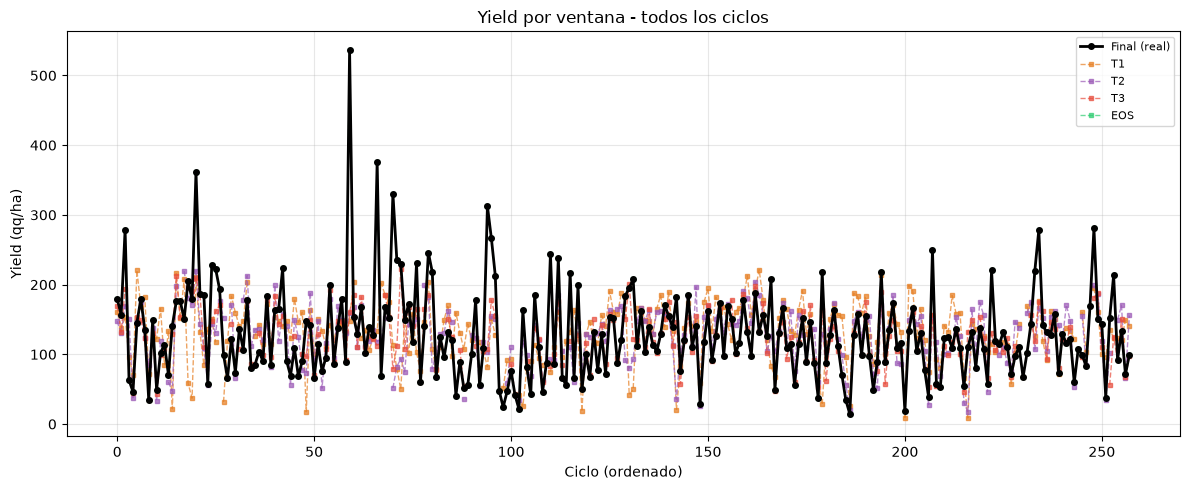

In [8]:
def graficar_fan_chart_agregado(df_conv):
    fig, ax = plt.subplots(figsize=(12, 5))
    df_plot = df_conv.sort_values("id_ciclo").copy()
    df_plot["order"] = range(len(df_plot))
    ax.plot(df_plot["order"], df_plot["yield_final_qq_ha"], "ko-", linewidth=2, markersize=4, label="Final (real)", zorder=5)
    colores = {"T1": "#e67e22", "T2": "#9b59b6", "T3": "#e74c3c", "EOS": "#2ecc71"}
    for v in ["T1", "T2", "T3", "EOS"]:
        col_y = f"yield_{v.lower()}_qq_ha"
        vals = df_plot[col_y].values
        ax.plot(df_plot["order"], vals, "s--", color=colores[v], linewidth=1, markersize=3, alpha=0.7, label=v)
    ax.set_xlabel("Ciclo (ordenado)")
    ax.set_ylabel("Yield (qq/ha)")
    ax.set_title("Yield por ventana - todos los ciclos")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

graficar_fan_chart_agregado(df_conv)


## 8. Tablero resumen

In [9]:
def tablero_resumen(df_conv, df_metricas):
    print("=" * 60)
    print("RESUMEN DE PREDICCIONES (Pipeline - desde BD)")
    print("=" * 60)
    print(f"Total ciclos evaluados: {len(df_conv)}")
    completos = df_conv.dropna(subset=["yield_t1_qq_ha", "yield_t2_qq_ha", "yield_t3_qq_ha", "yield_eos_qq_ha"])
    print(f"Ciclos con 4 ventanas: {len(completos)}")
    if "temporada" in df_conv.columns:
        temps = df_conv["temporada"].value_counts().to_dict()
        print(f"Temporadas: {temps}")
    print()
    print("--- Metricas de error ---")
    display(df_metricas.round(2))
    print("--- Top 10 errores absolutos (EOS) ---")
    top10 = df_conv.dropna(subset=["error_eos_qq_ha"]).nlargest(10, "error_eos_qq_ha")
    display(top10[["id_ciclo", "id_parcela", "temporada", "yield_final_qq_ha", "yield_eos_qq_ha", "error_eos_qq_ha"]])
    print("--- Ciclos con mejor prediccion EOS (error < 5%) ---")
    buenos = df_conv.dropna(subset=["error_pct_eos"]).copy()
    buenos = buenos[np.abs(buenos["error_pct_eos"]) < 5]
    print(f"Total: {len(buenos)}/{len(df_conv)} ({len(buenos)/len(df_conv)*100:.1f}%)")
    if not buenos.empty:
        display(buenos[["id_ciclo", "id_parcela", "temporada", "yield_final_qq_ha", "yield_eos_qq_ha", "error_pct_eos"]].head())

tablero_resumen(df_conv, df_metricas)


RESUMEN DE PREDICCIONES (Pipeline - desde BD)
Total ciclos evaluados: 258
Ciclos con 4 ventanas: 191
Temporadas: {'postrera': 147, 'primera': 111}

--- Metricas de error ---


,n,rmse_qq_ha,mae_qq_ha,mape_pct,bias_qq_ha,bias_pct,r2
ventana,,,,,,,
T1,247,70.04,50.71,44.94,0.62,20.49,0.06
T2,237,60.27,39.66,30.46,-5.77,7.41,0.21
T3,207,52.62,26.75,14.89,-16.09,-5.10,0.40
EOS,258,0.00,0.00,0.00,0.00,0.00,1.00


--- Top 10 errores absolutos (EOS) ---


,id_ciclo,id_parcela,temporada,yield_final_qq_ha,yield_eos_qq_ha,error_eos_qq_ha
0,2693,14,postrera,140.441881,140.441881,0.0
1,2725,17,primera,244.243500,244.243500,0.0
2,2737,18,primera,77.106841,77.106841,0.0
3,2791,4,primera,146.646110,146.646110,0.0
4,2755,2,primera,155.628728,155.628728,0.0
5,2805,5,primera,155.007672,155.007672,0.0
6,2779,3,primera,156.637934,156.637934,0.0
7,2705,15,primera,100.833998,100.833998,0.0
8,2847,8,primera,143.773076,143.773076,0.0
9,2615,0,primera,179.262083,179.262083,0.0


--- Ciclos con mejor prediccion EOS (error < 5%) ---
Total: 258/258 (100.0%)


,id_ciclo,id_parcela,temporada,yield_final_qq_ha,yield_eos_qq_ha,error_pct_eos
0,2693,14,postrera,140.441881,140.441881,0.0
1,2725,17,primera,244.243500,244.243500,0.0
2,2737,18,primera,77.106841,77.106841,0.0
3,2791,4,primera,146.646110,146.646110,0.0
4,2755,2,primera,155.628728,155.628728,0.0
